In [1]:
# 1. Import necessary libraries

# Numpy: Library for numerical computations and data processing
import numpy as np

# Pandas: Library for data analysis and manipulation
import pandas as pd

# Scikit-learn libraries for model building, training, and evaluation

# train_test_split: For splitting data into training and testing sets
from sklearn.model_selection import train_test_split

# DecisionTreeClassifier: To build and train the decision tree model
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Metrics: For model evaluation (accuracy, confusion matrix, etc.)
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Visualization libraries

# Matplotlib: For plotting graphs and visualizing data
import matplotlib.pyplot as plt

# Seaborn: For advanced statistical visualizations
import seaborn as sns

In [12]:
# 2. Load the dataset

# Load the stroke prediction dataset (Make sure the path to the dataset is correct)
stroke_data = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Display the first few rows of the dataset
stroke_data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [13]:
# 3. Handle missing values in the dataset

# Fill missing values in the 'bmi' column with the column's median value
stroke_data['bmi'] = stroke_data['bmi'].fillna(stroke_data['bmi'].median())

# Check for missing values in the dataset after filling
stroke_data.isna().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [14]:
# 4. Analyze and preprocess the data

# Count the number of instances for each class (0 = No Stroke, 1 = Stroke)
stroke_data['stroke'].value_counts()

0    4861
1     249
Name: stroke, dtype: int64

In [15]:
# 5. Convert categorical features to numerical using one-hot encoding

# Get columns with categorical data
categorical_columns = stroke_data.select_dtypes(['object']).columns

# Convert categorical columns to numeric values
stroke_data[categorical_columns] = stroke_data[categorical_columns].apply(lambda x: pd.factorize(x)[0])

# Display the dataset after transformation
stroke_data.head(2)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,0,67.0,0,1,0,0,0,228.69,36.6,0,1
1,51676,1,61.0,0,0,0,1,1,202.21,28.1,1,1


In [16]:

# 6. Drop unnecessary columns

# Remove the 'id' column from the dataset
stroke_data = stroke_data.drop(columns=['id'])

# Display the dataset after removing the 'id' column
stroke_data.head(2)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67.0,0,1,0,0,0,228.69,36.6,0,1
1,1,61.0,0,0,0,1,1,202.21,28.1,1,1


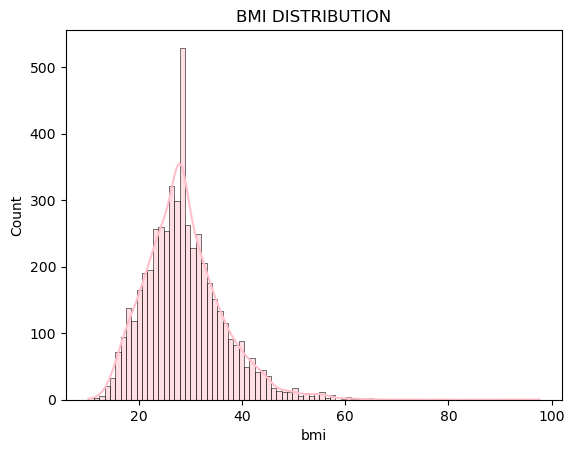

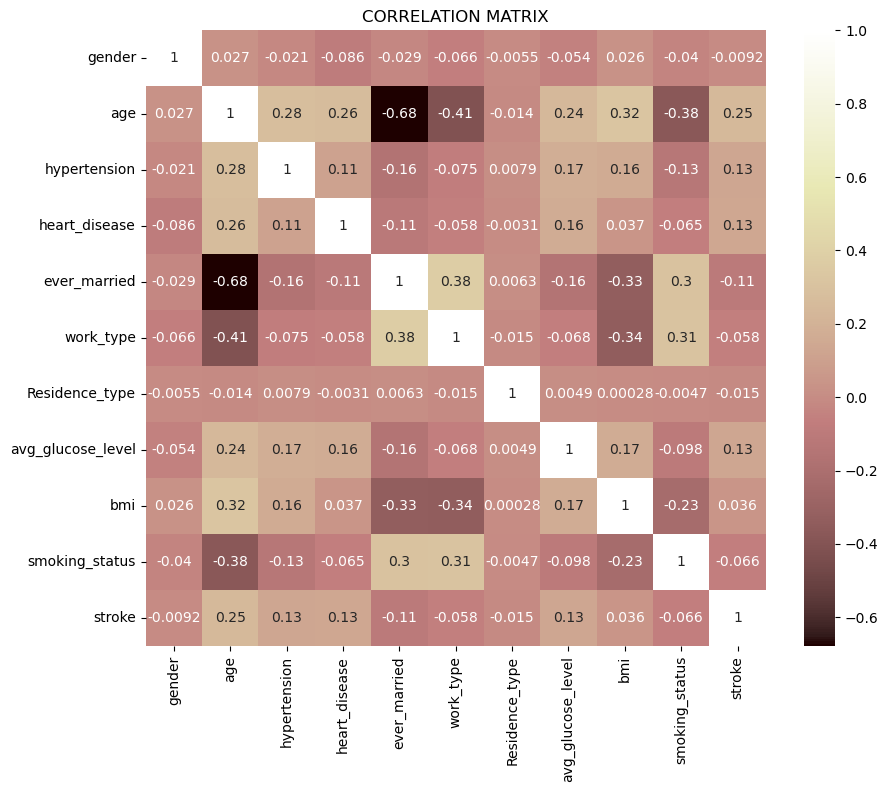

In [17]:
# 7. Visualize data distributions and correlations
# Generate a pair plot to visualize pairwise relationships and distributions of numerical features 
#sns.pairplot(strokeData)
# Plot the distribution of the 'bmi' numerical feature with a KDE (Kernel Density Estimate) overlay 
sns.histplot(stroke_data['bmi'].dropna(), kde=True, color='pink')
plt.title('BMI DISTRIBUTION')
plt.show()

# Plot the correlation matrix with a pink color palette
plt.figure(figsize=(10, 8))
sns.heatmap(stroke_data.corr(), annot=True, cmap='pink')
plt.title('CORRELATION MATRIX')
plt.show()

In [18]:
# 8. Define feature matrix (X) and target variable (y)

# Remove the 'stroke' column to create the feature matrix X
X = stroke_data.drop(columns=['stroke'])

# Assign the 'stroke' column as the target variable y
y = stroke_data['stroke']

In [19]:
# 9. Split the dataset into training and testing sets

# Use train_test_split to split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

# Display first few rows of training data
X_train.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
1098,1,77.0,0,0,0,0,1,75.06,22.0,3
3465,1,28.0,0,0,0,0,1,141.16,36.7,1
3160,1,17.0,0,0,1,0,1,88.65,30.3,1
3594,1,62.0,0,0,0,0,1,226.38,47.4,1
1249,0,15.0,0,0,1,0,1,78.59,25.1,3


In [20]:
# Display first few rows of testing data
X_test.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
2918,1,63.0,0,1,0,1,1,239.95,32.2,2
3056,0,62.0,0,1,0,2,1,73.70,26.2,1
4916,0,54.0,0,0,0,2,0,72.96,37.7,2
4003,1,24.0,0,0,1,0,1,147.74,21.4,3
3332,0,27.0,0,0,0,0,0,114.32,28.1,3


In [21]:
# 10. Train a Decision Tree Classifier

# Create a decision tree classifier using entropy criterion
# Handle overfitting using cross-validation

decision_tree_classifier = DecisionTreeClassifier(criterion="entropy", random_state=42, max_depth=3, min_samples_leaf=5)

# Train the classifier using the training data
decision_tree_classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=5,
                       random_state=42)

In [22]:
# 11. Make predictions using the test set

# Use the trained classifier to make predictions on the test data
y_pred = decision_tree_classifier.predict(X_test)

In [23]:
# 12. Evaluate model performance

# Calculate the confusion matrix
confusion_mat = confusion_matrix(y_test, y_pred)

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)

# Get detailed classification report
classification_report_metrics = classification_report(y_test, y_pred)

# Print model evaluation results
print("Confusion Matrix:\n", confusion_mat)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report_metrics)

Confusion Matrix:
 [[976   0]
 [ 46   0]]
Accuracy: 0.95
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98       976
           1       0.00      0.00      0.00        46

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.91      0.95      0.93      1022



/Users/karinamurpani/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/karinamurpani/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/karinamurpani/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


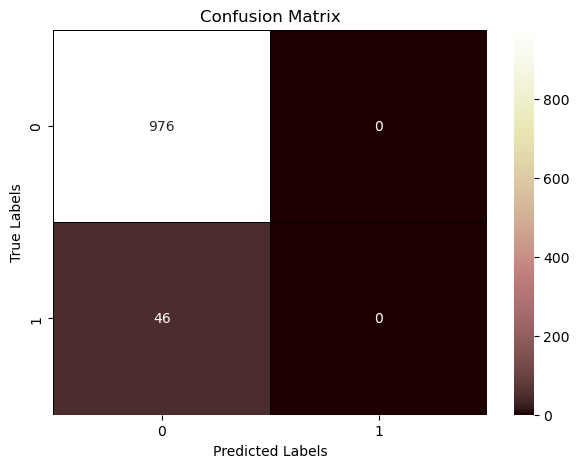

In [24]:
# 13. Visualize the confusion matrix using a heatmap

# Generate a heatmap for the confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='pink', linewidths=0.5, linecolor='black')

# Add axis labels and a title
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

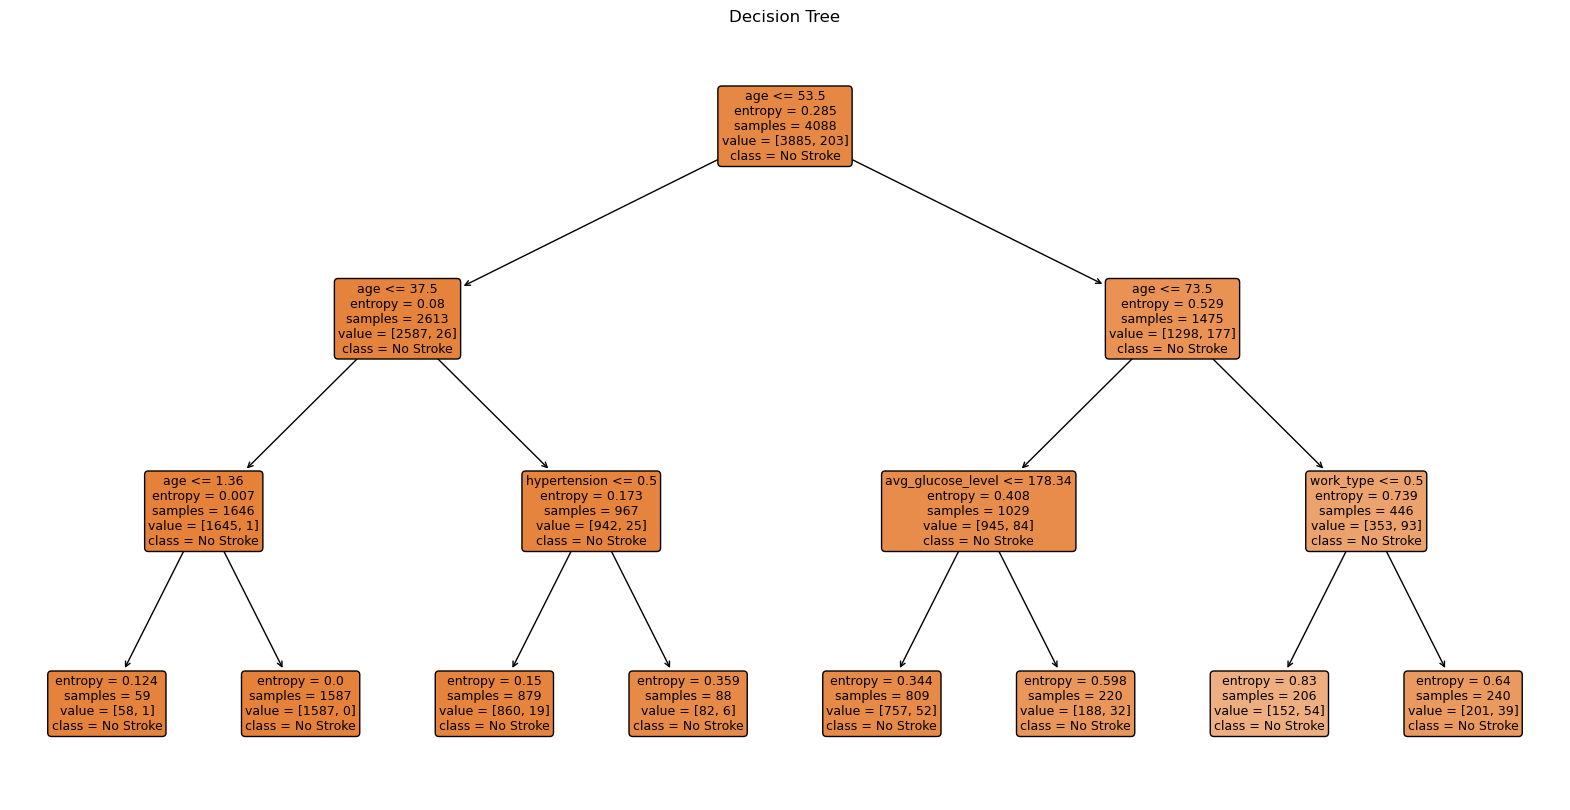

In [25]:
# 14. Visualize the decision tree

# Set the figure size for the tree plot
plt.figure(figsize=(20, 10))

# Plot the decision tree
plot_tree(decision_tree_classifier, feature_names=X.columns, class_names=['No Stroke', 'Stroke'], filled=True, rounded=True)

# Add a title to the plot
plt.title('Decision Tree')

# Show the plot
plt.show()